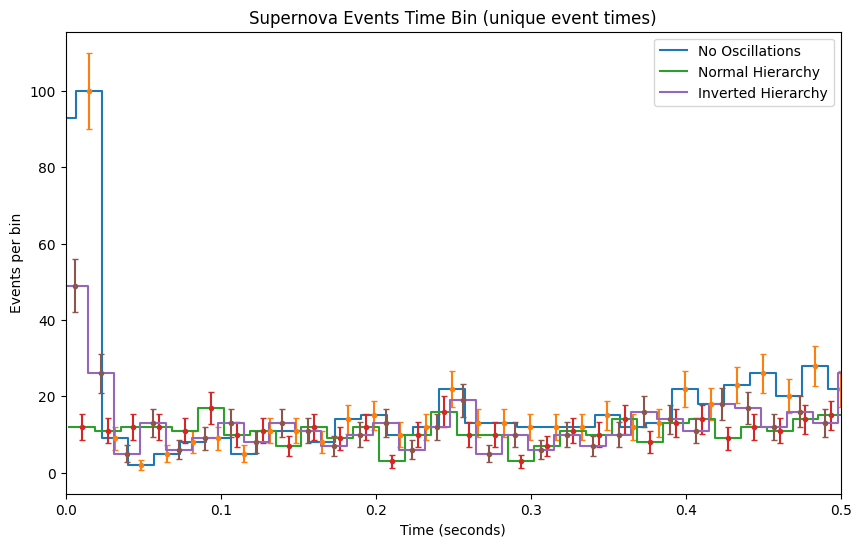

In [12]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

# --- List of ROOT files ---
files = {
    "No Oscillations": "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_events.root",
    "Normal Hierarchy": "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_NH_events.root",
    "Inverted Hierarchy": "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_IH_events.root",
}
bin_edges = np.array([
  0.004228276877761416, 0.005228276877761416, 0.0072901325478645085, 0.008762886597938148, 
    0.010235640648011787, 0.012002945508100153, 0.012297496318114873, 0.014064801178203246, 
    0.016421207658321064, 0.019366715758468343,0.02260677466863034, 
    0.026435935198821807, 0.030559646539027978, 0.036156111929307816, 0.04175257731958763, 
    0.04852724594992637, 0.05677466863033874, 0.06620029455081003, 0.07680412371134022, 
    0.0894698085419735, 0.10419734904270989, 0.12187039764359353, 0.14189985272459502, 
    0.1651693667157585, 0.19226804123711344, 0.2237849779086893, 
    0.25
])


plt.figure(figsize=(10,6))

for label, filepath in files.items():
    file = uproot.open(filepath)
    tree = file["G4_Photons"]

    # Read branches
    event_id = tree["event_id"].array()
    photon_t = tree["photon_hit_t"].array() * 1e-9  # ns → s

    # Flatten into numpy
    event_id_flat = ak.to_numpy(ak.flatten(event_id))
    photon_t_flat = ak.to_numpy(ak.flatten(photon_t))

    # For each unique event_id, take the first photon time
    event_times = []
    for eid in np.unique(event_id_flat):
        mask = event_id_flat == eid
        first_time = np.min(photon_t_flat[mask])
        event_times.append(first_time)
    event_times = np.array(event_times)

    # Histogram of event times
    counts, edges = np.histogram(event_times, bins=500)
    errors = np.sqrt(counts)

    centers = 0.5 * (edges[1:] + edges[:-1])
    plt.step(edges[:-1], counts, where="post", label=label)
    plt.errorbar(centers, counts, yerr=errors, fmt=".", capsize=2)

# --- Vertical lines for phases ---
#for x in [0.02, 0.07, 0.22]:
#    plt.axvline(x=x, color="red", linestyle="--")

plt.xlabel("Time (seconds)")
plt.ylabel("Events per bin")

plt.title("Supernova Events Time Bin (unique event times)")
plt.xlim(0.0, 0.5)
plt.legend()
plt.show()

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# --- File Path ---
filepath = "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_100events.root"

# Open the file and the tree
file = uproot.open(filepath)
# Note: Check if your tree is named "event_tree" or "metadata" 
# Based on our previous debug, "event_tree" is the one with 96 entries
tree = file["event_tree"] 

# 1. Extract the neutrino energy
# Branch name in MARLEY/QPix is usually 'nu_energy' or 'E_nu'
nu_energy = tree["nu_energy"].array(library="np")

plt.figure(figsize=(8, 5))

# 2. Plot the Histogram of simulated energies
counts, bins, _ = plt.hist(nu_energy, bins=20, range=(0, 60), 
                           histtype='step', linewidth=2, label='Simulated (96 events)')

# 3. Add labels and title
plt.xlabel("Neutrino Energy [MeV]")
plt.ylabel("Number of Events")
plt.title("Simulated Neutrino Energy Spectrum (Bollig Model)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(f"Successfully plotted {len(nu_energy)} events.")

In [ ]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

# --- List of ROOT files ---
files = {
    "No Oscillations": "/media/argon/5TB1_rooks/Supernova_Neutrinos/Bollig/NOscillations/nusperbin2d_NOscillations_Nakazato_1000events.root",
   # "Normal Ordering": "/media/argon/5TB1_jacob/Supernova_Neutrinos/Garching/NH/nusperbin2d_NHOscillations_1000events.root",
   # "Inverted Ordering": "/media/argon/5TB1_jacob/Supernova_Neutrinos/Garching/IH/nusperbin2d_IHOscillations_1000events.root",
}

bin_edges = np.array([
    0.004228276877761416, 0.005228276877761416, 0.0072901325478645085, 0.008762886597938148, 
    0.010235640648011787, 0.012002945508100153, 0.012297496318114873, 0.014064801178203246, 
    0.016421207658321064, 0.019366715758468343, 0.02260677466863034, 
    0.026435935198821807, 0.030559646539027978, 0.036156111929307816, 0.04175257731958763, 
    0.04852724594992637, 0.05677466863033874, 0.06620029455081003, 0.07680412371134022, 
    0.0894698085419735, 0.10419734904270989, 0.12187039764359353, 0.14189985272459502, 
    0.1651693667157585, 0.19226804123711344, 0.2237849779086893, 
    0.25
])

plt.figure(figsize=(10,6))

for label, filepath in files.items():
    file = uproot.open(filepath)
    tree = file["G4_Photons"]
    
    # Read branches
    event_id = tree["event_id"].array()
    photon_t = tree["photon_hit_t"].array() * 1e-9  # ns → s
    
    # Flatten into numpy
    event_id_flat = ak.to_numpy(ak.flatten(event_id))
    photon_t_flat = ak.to_numpy(ak.flatten(photon_t))
    
    # For each unique event_id, take the first photon time
    event_times = []
    for eid in np.unique(event_id_flat):
        mask = event_id_flat == eid
        first_time = np.min(photon_t_flat[mask])
        event_times.append(first_time)
    event_times = np.array(event_times)
    
    # Histogram of event times
    counts, edges = np.histogram(event_times, bins=bin_edges)
    
    # Calculate bin widths
    bin_widths = edges[1:] - edges[:-1]
    
    # Area normalize: divide counts by (bin_width * total_counts)
    # This makes the integral of the histogram equal to 1
    total_area = np.sum(counts * bin_widths)
    normalized_counts = counts / total_area
    
    # Propagate errors for normalized counts
    errors = np.sqrt(counts) / total_area
    
    centers = 0.5 * (edges[1:] + edges[:-1])
    
    plt.step(edges[:-1], normalized_counts, where="post", label=label)
    plt.errorbar(centers, normalized_counts, yerr=errors, fmt=".", capsize=2)

# --- Vertical lines for phases ---
for x in [0.02, 0.07, 0.22]:
    plt.axvline(x=x, color="red", linestyle="--")

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Events per bin (1/s)")
plt.title("Area-Normalized Supernova Events Time Distribution")
plt.xlim(0.0, 0.23)
plt.legend()
plt.show()